
           QUANTSTATS PERFORMANCE METRICS
Sharpe Ratio:  1.02
Sortino Ratio: 58.65
Max Drawdown:  -100.00%
Win Rate:      45.16%

Interactive HTML tearsheet saved to:
 c:\Users\UTTESH\strategy_report.html



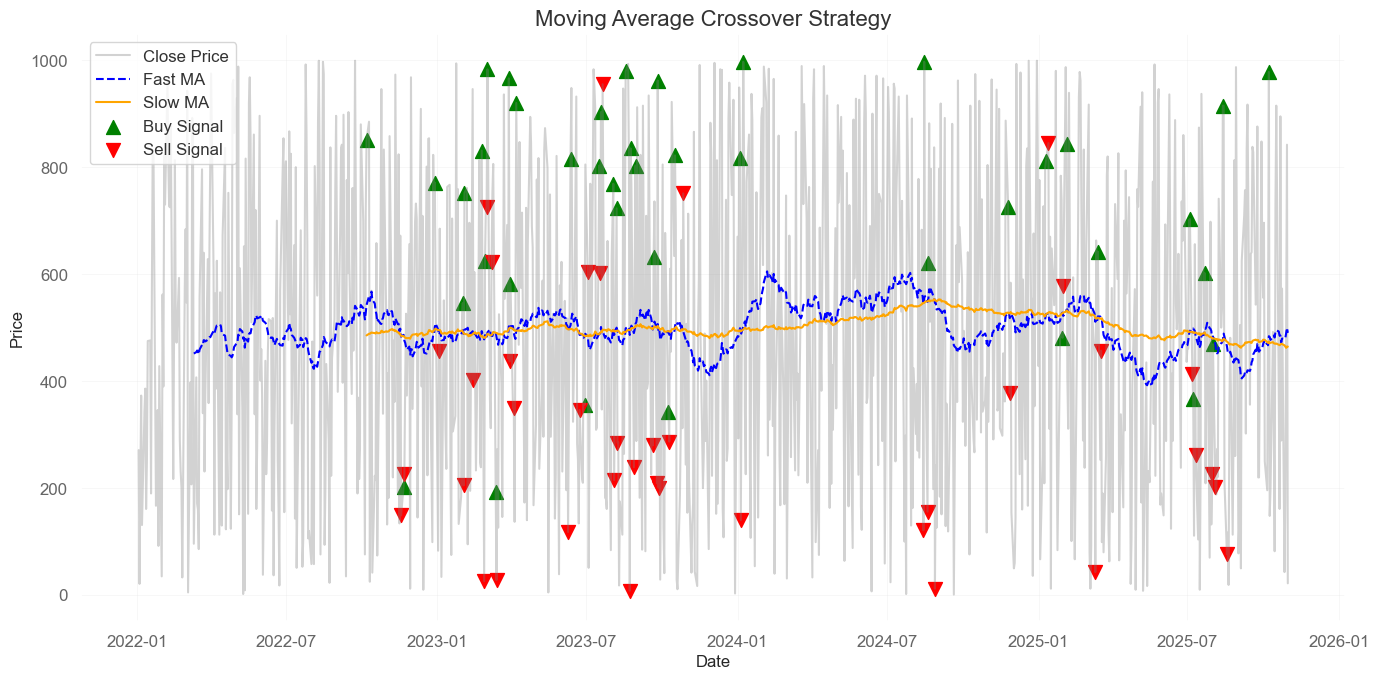

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import quantstats as qs

# Extended quantstats functionality
qs.extend_pandas()

# 1. Generate the random data (1000 rows, 4 columns)
np.random.seed(42)  # Added for reproducibility
Data = np.random.randint(1, 1000, (1000, 4))

# 2. Create the DataFrame with column names
df1 = pd.DataFrame(Data, columns=["Open", "High", "Low", "Close"])

# Create a proper DatetimeIndex since QuantStats requires time-series data
df1.index = pd.date_range(start="2022-01-01", periods=len(df1), freq="B")


# 3. Define the Signal Generation Function
def generate_ma_crossover_signals(
    data: pd.DataFrame, fast_window: int, slow_window: int
) -> pd.DataFrame:
    """Generates trading signals based on a Moving Average Crossover strategy."""
    df = data.copy()

    # Calculate the Moving Averages
    df["Fast_MA"] = df["Close"].rolling(window=fast_window).mean()
    df["Slow_MA"] = df["Close"].rolling(window=slow_window).mean()

    # Create a position flag: 1 when Fast is above Slow, 0 otherwise
    df["Position"] = np.where(df["Fast_MA"] > df["Slow_MA"], 1, 0)

    # The signal is the day-to-day change in position
    df["Signal"] = df["Position"].diff()

    # Clean up the NaN rows caused by the diff() and fill with 0 (Hold)
    df["Signal"] = df["Signal"].fillna(0).astype(int)

    return df


# 4. Define the Performance Evaluation Function
def evaluate_performance(df: pd.DataFrame, report_path: str = "strategy_report.html"):
    """Evaluates strategy performance using QuantStats against a Buy & Hold benchmark."""
    # Step A: Calculate baseline asset returns (Buy & Hold)
    df["Asset_Returns"] = df["Close"].pct_change()

    # Step B: Shift position by 1 day to avoid lookahead bias
    # (You enter the trade at the next day's open/close after signal triggers)
    df["Strategy_Returns"] = df["Position"].shift(1) * df["Asset_Returns"]
    df["Strategy_Returns"] = df["Strategy_Returns"].fillna(0)

    # Step C: Print core metrics directly to the terminal
    print("\n" + "="*50)
    print("           QUANTSTATS PERFORMANCE METRICS")
    print("="*50)
    print(f"Sharpe Ratio:  {qs.stats.sharpe(df['Strategy_Returns']):.2f}")
    print(f"Sortino Ratio: {qs.stats.sortino(df['Strategy_Returns']):.2f}")
    print(f"Max Drawdown:  {qs.stats.max_drawdown(df['Strategy_Returns']) * 100:.2f}%")
    print(f"Win Rate:      {qs.stats.win_rate(df['Strategy_Returns']) * 100:.2f}%")
    print("="*50 + "\n")

    # Step D: Generate full interactive HTML tearsheet
    qs.reports.html(
        df["Strategy_Returns"], 
        benchmark=df["Asset_Returns"], 
        output=report_path, 
        title="MA Crossover Strategy Performance"
    )
    
    absolute_path = os.path.abspath(report_path)
    print(f"Interactive HTML tearsheet saved to:\n {absolute_path}\n")


# 5. Define the Visualization Function
def plot_signals(df: pd.DataFrame, save_path: str = "trading_strategy.png"):
    """Plots the Close price, Moving Averages, and Buy/Sell signals."""
    plt.figure(figsize=(14, 7))

    # Plot Close Price and Moving Averages
    plt.plot(df.index, df["Close"], label="Close Price", alpha=0.35, color="gray")
    plt.plot(df.index, df["Fast_MA"], label="Fast MA", color="blue", linestyle="--")
    plt.plot(df.index, df["Slow_MA"], label="Slow MA", color="orange", linestyle="-")

    # Plot Buy Signals
    buy_signals = df[df["Signal"] == 1]
    plt.scatter(buy_signals.index, buy_signals["Close"], label="Buy Signal", marker="^", color="green", s=100)

    # Plot Sell Signals
    sell_signals = df[df["Signal"] == -1]
    plt.scatter(sell_signals.index, sell_signals["Close"], label="Sell Signal", marker="v", color="red", s=100)

    # Formatting
    plt.title("Moving Average Crossover Strategy", fontsize=16)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Price", fontsize=12)
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Save image
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


# 6. Run the strategy (e.g., 50-day and 200-day MA)
df_signals = generate_ma_crossover_signals(df1, fast_window=50, slow_window=200)

# 7. Evaluate performance via QuantStats
evaluate_performance(df_signals, report_path="strategy_report.html")

# 8. Visualize the chart
plot_signals(df_signals, save_path="trading_strategy.png")